In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Features: [study_hours, attendance_percent, sleep_hours]
X = np.array([
    [1.0, 55, 5.0],
    [2.0, 60, 5.5],
    [2.5, 62, 6.0],
    [3.0, 65, 5.0],
    [3.5, 70, 6.5],
    [4.0, 72, 6.0],
    [4.5, 75, 6.5],
    [5.0, 78, 7.0],
    [5.5, 80, 6.5],
    [6.0, 82, 7.0],
    [6.5, 85, 7.5],
    [7.0, 88, 8.0]
], dtype=float)

# Target: 0 = fail, 1 = pass
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=float)

m, n = X.shape

print("X shape:",X.shape)
print("y shape:",y.shape)
print("m =", m, ", n =", n)



X shape: (12, 3)
y shape: (12,)
m = 12 , n = 3


In [17]:
def standardize_features(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma==0] = 1.0
    X_scaled = (X - mu) / sigma

    return X_scaled, mu, sigma

def apply_standardization(X, mu, sigma):
    return (X - mu) / sigma

X_scaled, mu, sigma = standardize_features(X)

print("\nFeature means:", mu)
print("Feature std:", sigma)
print("Scaled X:\n", X_scaled)



Feature means: [ 4.20833333 72.66666667  6.375     ]
Feature std: [ 1.79650509 10.06092552  0.89267855]
Scaled X:
 [[-1.78587489 -1.75596834 -1.54030809]
 [-1.22923856 -1.25899617 -0.98019606]
 [-0.95092039 -1.0602073  -0.42008403]
 [-0.67260223 -0.762024   -1.54030809]
 [-0.39428407 -0.26505182  0.14002801]
 [-0.1159659  -0.06626296 -0.42008403]
 [ 0.16235226  0.23192035  0.14002801]
 [ 0.44067043  0.53010365  0.70014004]
 [ 0.71898859  0.72889252  0.14002801]
 [ 0.99730676  0.92768139  0.70014004]
 [ 1.27562492  1.22586469  1.26025208]
 [ 1.55394308  1.52404799  1.82036411]]


In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [19]:
def predict_probability(x, w, b):
    z = np.dot(w, x) + b
    return sigmoid(z)

In [20]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    epsilon = 1e-10 #avoids log(0)

    for i in range(m):
        f_wb = predict_probability(X[i], w, b)

        # clip prediction so log never gets 0
        f_wb = np.clip(f_wb, epsilon, 1 - epsilon)

        cost += -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)
    return cost / m

In [21]:
def compute_gradient(X, y, w, b):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = predict_probability(X[i] , w, b)
        error = f_wb - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i, j]

        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [22]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w =  w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
        
    return w, b, cost_history

In [23]:
def predict_class(X, w, b, threshold=0.5):
    m = X.shape[0]
    predictions = np.zeros(m)

    for i in range(m):
        prob = predict_probability(X[i] , w, b)
        predictions[i] = 1 if prob >= threshold else 0

    return predictions

In [24]:
def compute_accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)

    return correct / len(y_true)

In [32]:
w = np.zeros(n)
b = 0.0

alpha = 0.1
iterations = 10000

In [34]:
w, b, cost_history = gradient_descent(X_scaled, y, w, b, alpha, iterations)
print("\nFinal Paramters:")
print("w =",w)
print("b =", b)

Iteration 0: Cost = 0.0157
Iteration 100: Cost = 0.0155
Iteration 200: Cost = 0.0154
Iteration 300: Cost = 0.0153
Iteration 400: Cost = 0.0151
Iteration 500: Cost = 0.0150
Iteration 600: Cost = 0.0149
Iteration 700: Cost = 0.0147
Iteration 800: Cost = 0.0146
Iteration 900: Cost = 0.0145
Iteration 1000: Cost = 0.0144
Iteration 1100: Cost = 0.0143
Iteration 1200: Cost = 0.0141
Iteration 1300: Cost = 0.0140
Iteration 1400: Cost = 0.0139
Iteration 1500: Cost = 0.0138
Iteration 1600: Cost = 0.0137
Iteration 1700: Cost = 0.0136
Iteration 1800: Cost = 0.0135
Iteration 1900: Cost = 0.0134
Iteration 2000: Cost = 0.0133
Iteration 2100: Cost = 0.0132
Iteration 2200: Cost = 0.0131
Iteration 2300: Cost = 0.0130
Iteration 2400: Cost = 0.0129
Iteration 2500: Cost = 0.0128
Iteration 2600: Cost = 0.0127
Iteration 2700: Cost = 0.0126
Iteration 2800: Cost = 0.0125
Iteration 2900: Cost = 0.0124
Iteration 3000: Cost = 0.0123
Iteration 3100: Cost = 0.0123
Iteration 3200: Cost = 0.0122
Iteration 3300: Cost =

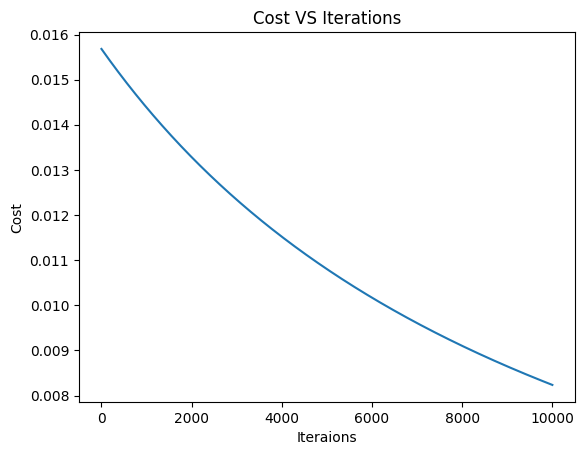

In [35]:
plt.plot(cost_history)
plt.title("Cost VS Iterations")
plt.xlabel("Iteraions")
plt.ylabel("Cost")
plt.show()

In [36]:
y_pred = predict_class(X_scaled, w, b)
accuracy = compute_accuracy(y, y_pred)

print("\nPredicted classes:", y_pred)
print("Actual classes:   ", y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")


Predicted classes: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
Actual classes:    [0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
Training Accuracy: 100.00%


In [41]:
new_student = np.array([[1.0, 55, 5.0]], dtype=float)

new_student_scaled = apply_standardization(new_student, mu, sigma)

probability = predict_probability(new_student_scaled[0], w, b)

predicted_class = 1 if probability >= 0.5 else 0

print("\nNew student:", new_student[0])
print(f"Predicted probability of passing: {probability:.10f}")
print("Predicted class:", predicted_class)


New student: [ 1. 55.  5.]
Predicted probability of passing: 0.0000000001
Predicted class: 0
